<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nelson/customer_segmentation_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os

from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import plotly.graph_objs as go

# **Data Loading**


In [81]:
# Mengambil dataset dari Kaggle
if not os.path.exists('Online Retail.csv'):
  files.upload()
  print("Success")

  os.mkdir('/root/.kaggle')
  !cp kaggle.json ~/.kaggle/

  !chmod 600 ~/.kaggle/kaggle.json
  !kaggle datasets download -d viridianachow/online-retail-uci-dataset
  !unzip online-retail-uci-dataset.zip

In [82]:
df = pd.read_csv('Online Retail.csv')

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


## **Exploratory Data Analysis (EDA)**

In [83]:
sns.set_style("whitegrid")

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [85]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


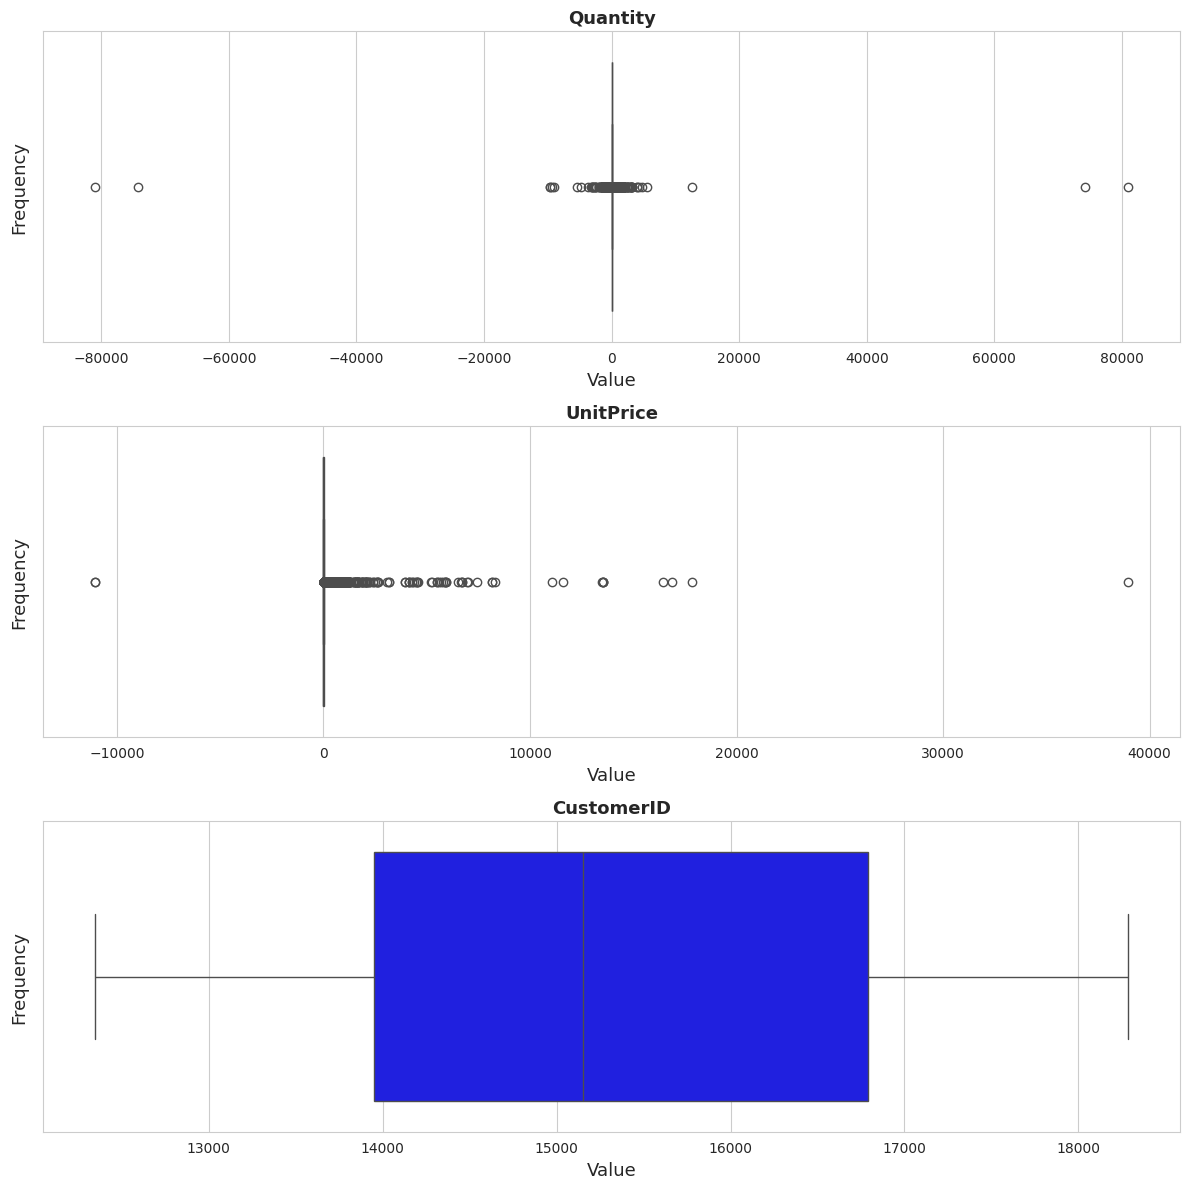

In [86]:
# Menampilkan Box Plot kolom numeric
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_vars = df[numerical_cols].shape[1]

n_cols = 1
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(df[numerical_cols].columns):
    sns.boxplot(x=df[column], ax=axes[i], color='blue')
    axes[i].set_title(column, fontsize=13, weight='bold')
    axes[i].set_xlabel('Value', fontsize=13)
    axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

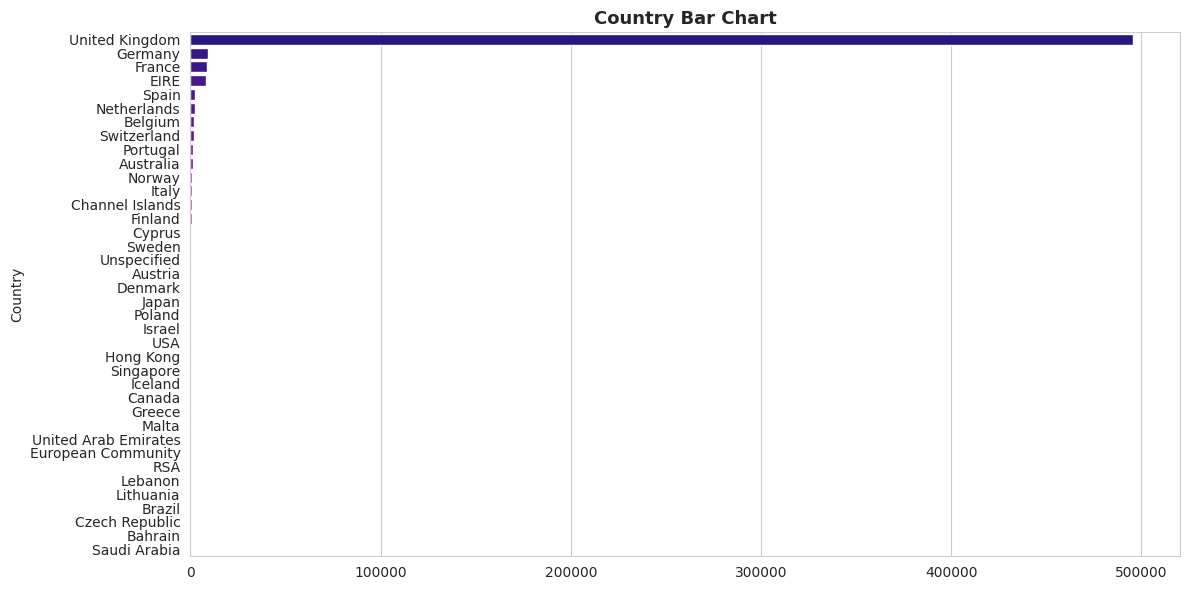

In [87]:
# Menampilkan Bar Chart persebaran kolom Country
country = df['Country'].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.barplot(x=country.values, y=country.index, palette='plasma', hue=country.index)
ax.set_title('Country Bar Chart', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

In [88]:
df_lencoder = df.copy()
categorical_cols = df.select_dtypes(include=['object']).columns

for column in df_lencoder[categorical_cols].columns:
    label_encoder = LabelEncoder()
    df_lencoder[column] = label_encoder.fit_transform(df_lencoder[column].astype(str))

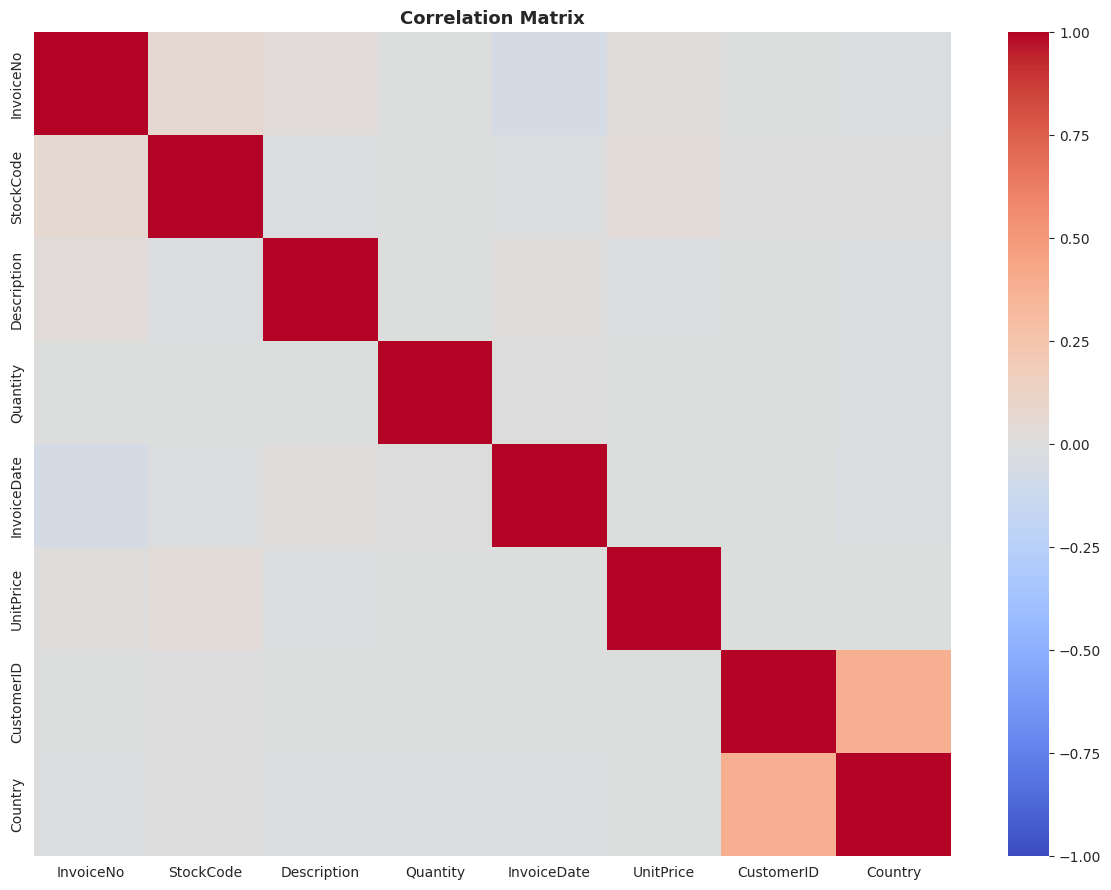

In [89]:
# Menampilkan Heatmap korelasi antar data
correlation_matrix = df_lencoder.corr()

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

sns.heatmap(data=correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Matrix', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

# **Pre-processing**

## Raw Data

In [90]:
df.duplicated().sum()

np.int64(5268)

In [91]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [92]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [93]:
df.dropna(inplace=True)
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [94]:
# Memperbaiki format data masing-masing kolom
categorical_cols = ['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Country']
numerical_cols = ['Quantity', 'UnitPrice']

for column in categorical_cols:
    df[column] = df[column].astype(str)

for column in numerical_cols:
    df[column] = df[column].astype(float)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [95]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,401604,401604,401604,401604.000000,401604,401604.000000,401604,401604
unique,22190,3684,3896,NaN,NaN,NaN,4372,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841.0,United Kingdom
freq,542,2065,2058,NaN,NaN,NaN,7812,356728
mean,NaN,NaN,NaN,12.183273,2011-07-10 12:08:23.848567552,3.474064,NaN,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,0.000000,NaN,NaN
25%,NaN,NaN,NaN,2.000000,2011-04-06 15:02:00,1.250000,NaN,NaN
50%,NaN,NaN,NaN,5.000000,2011-07-29 15:40:00,1.950000,NaN,NaN
75%,NaN,NaN,NaN,12.000000,2011-10-20 11:58:30,3.750000,NaN,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,NaN,NaN


In [96]:
min_date = df['InvoiceDate'].min()
df[df['InvoiceDate'] == min_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,4.25,17850.0,United Kingdom


In [97]:
# Menghapus transaksi sebelum tahun 2011 agar total Bulan seimbang
start_date = "2011-01-01 00:00:00"

df.drop(df[df['InvoiceDate'] < start_date].index, inplace=True)

min_date = df['InvoiceDate'].min()
df[df['InvoiceDate'] == min_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
42481,539993,22386,JUMBO BAG PINK POLKADOT,10.0,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
42482,539993,21499,BLUE POLKADOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42483,539993,21498,RED RETROSPOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42484,539993,22379,RECYCLING BAG RETROSPOT,5.0,2011-01-04 10:00:00,2.10,13313.0,United Kingdom
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10.0,2011-01-04 10:00:00,1.25,13313.0,United Kingdom
42486,539993,85099B,JUMBO BAG RED RETROSPOT,10.0,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
42487,539993,20682,RED RETROSPOT CHILDRENS UMBRELLA,6.0,2011-01-04 10:00:00,3.25,13313.0,United Kingdom
42488,539993,22961,JAM MAKING SET PRINTED,12.0,2011-01-04 10:00:00,1.45,13313.0,United Kingdom
42489,539993,22667,RECIPE BOX RETROSPOT,6.0,2011-01-04 10:00:00,2.95,13313.0,United Kingdom
42490,539993,22898,CHILDRENS APRON APPLES DESIGN,8.0,2011-01-04 10:00:00,1.95,13313.0,United Kingdom


In [98]:
# Menghapus transaksi di luar United Kingdom
df.drop(df[df['Country'] != 'United Kingdom'].index, inplace=True)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
42481,539993,22386,JUMBO BAG PINK POLKADOT,10.0,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
42482,539993,21499,BLUE POLKADOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42483,539993,21498,RED RETROSPOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42484,539993,22379,RECYCLING BAG RETROSPOT,5.0,2011-01-04 10:00:00,2.10,13313.0,United Kingdom
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10.0,2011-01-04 10:00:00,1.25,13313.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8.0,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


### Feature Engineering


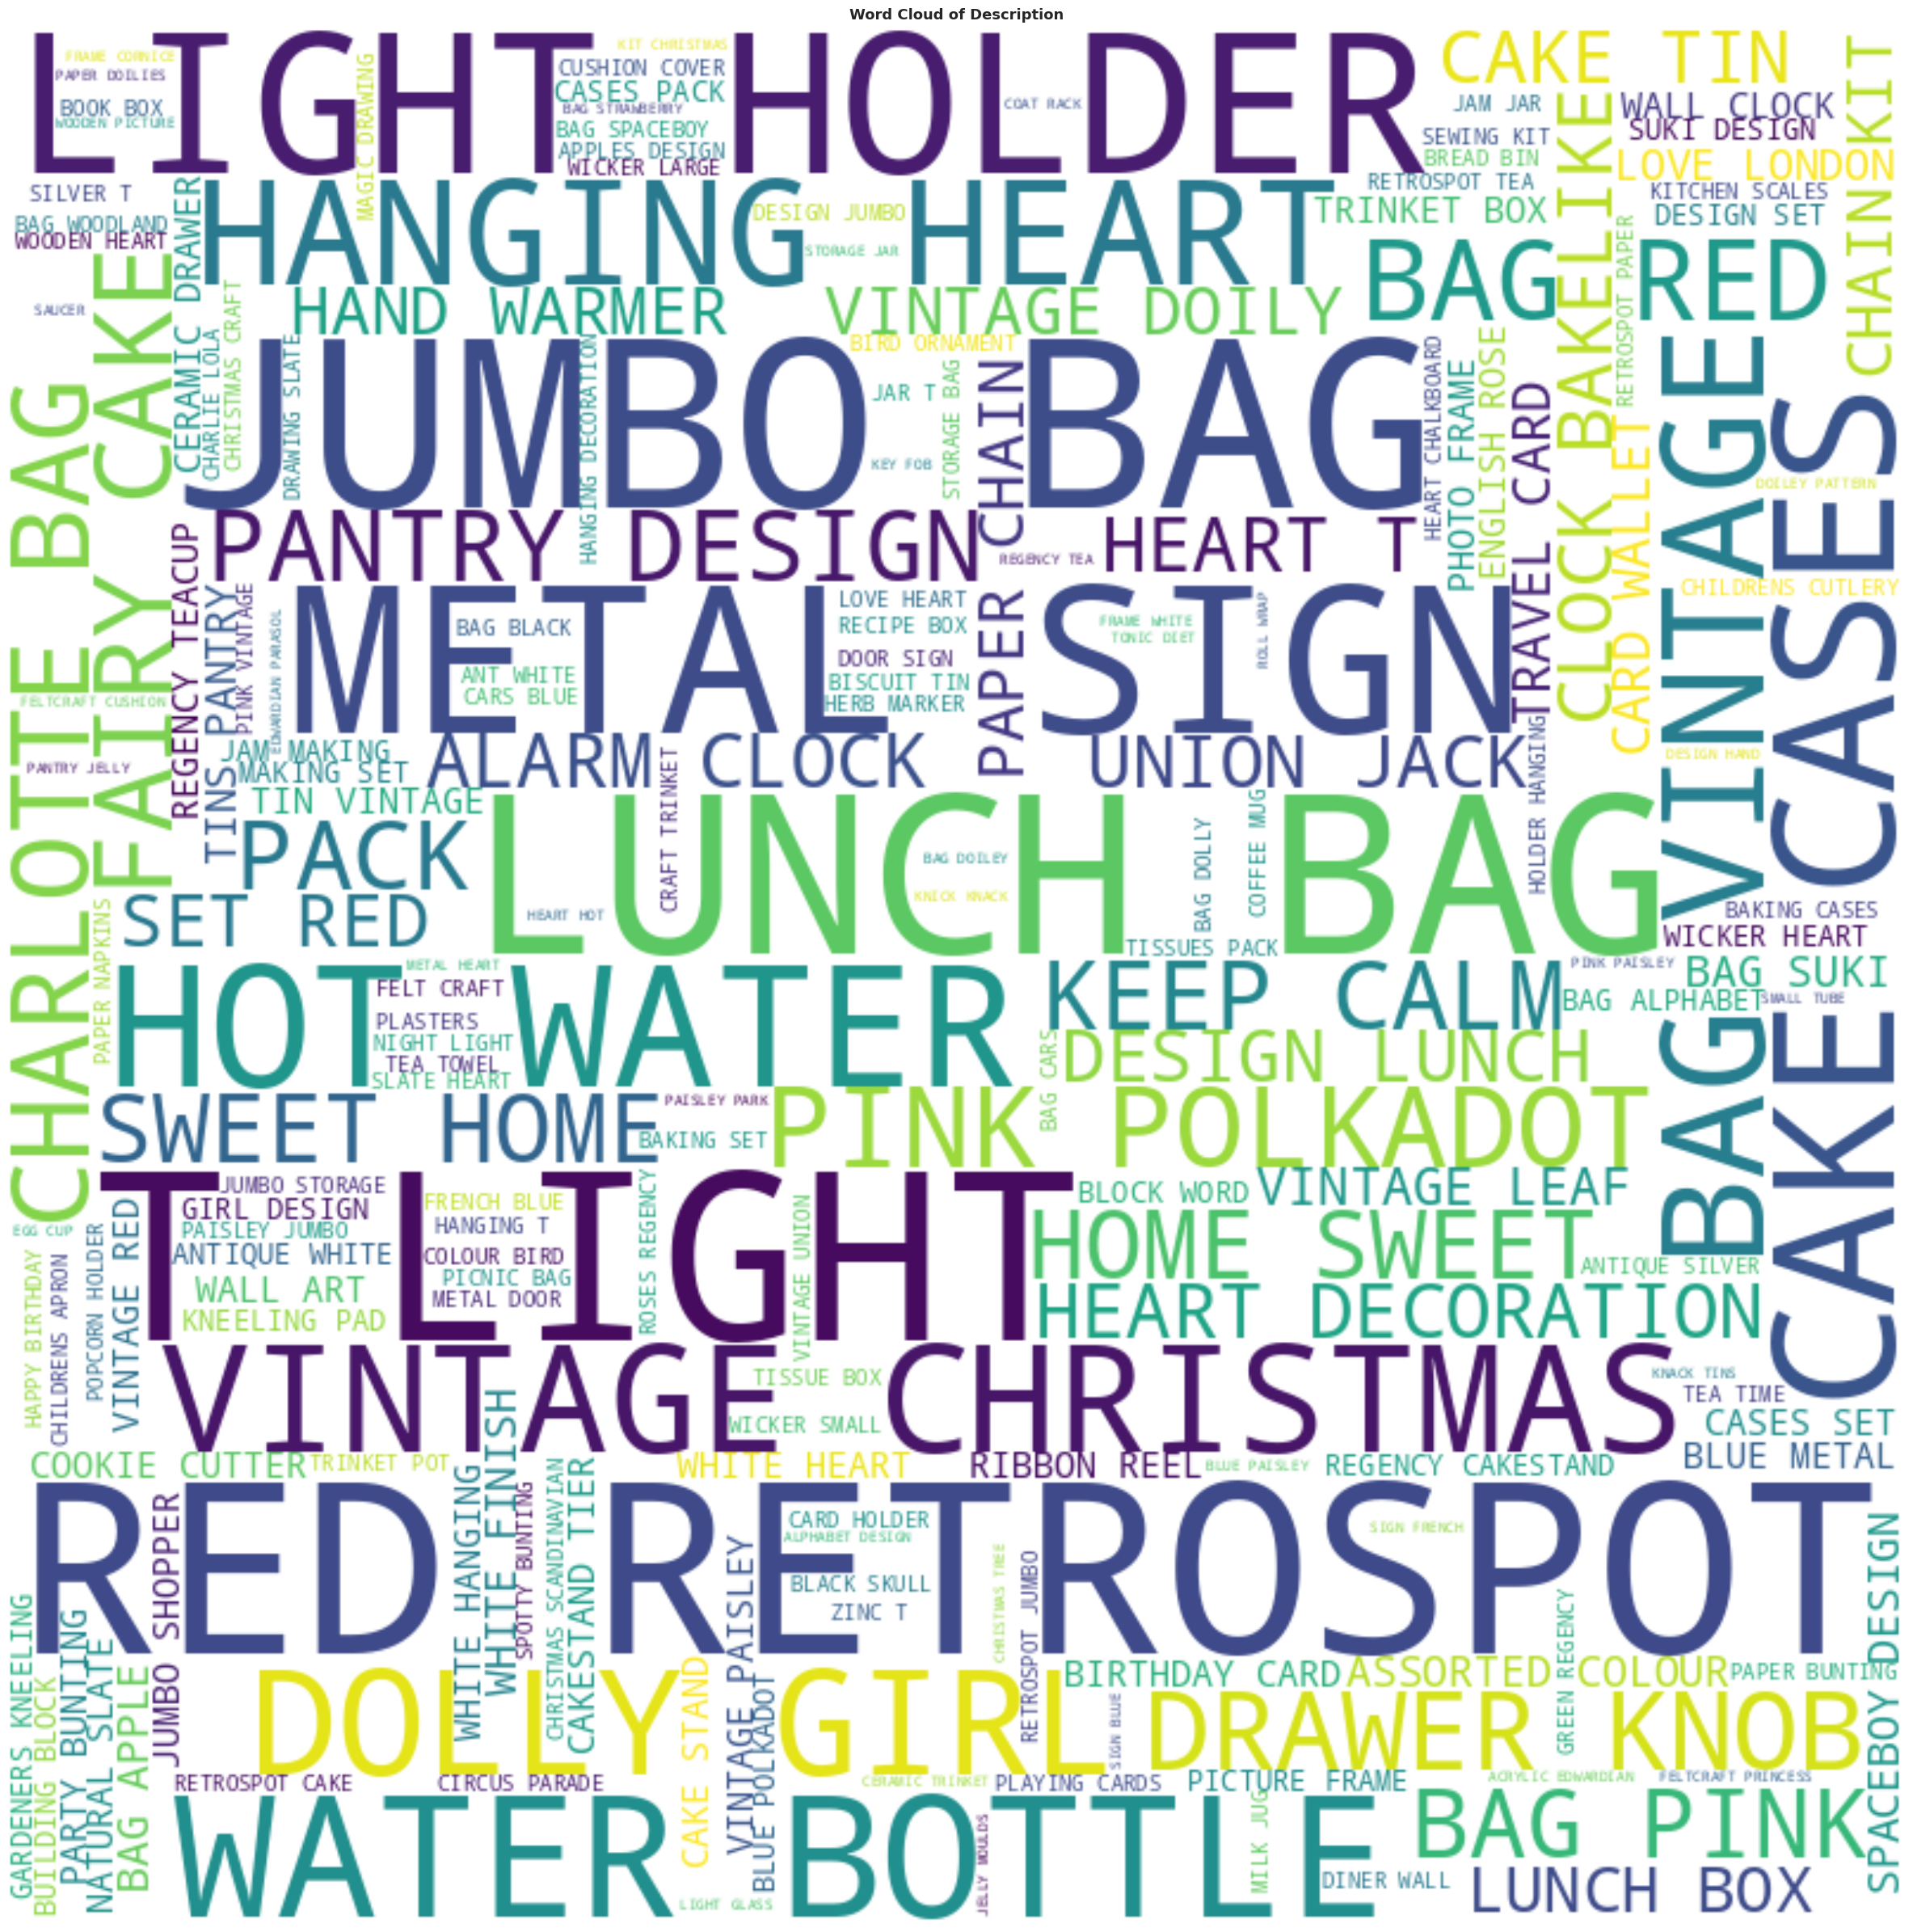

In [99]:
# Menampilkan WordCloud kolom Description
list_text = ' '.join(df['Description'])
wc = WordCloud(width=800, height=800, background_color='white').generate(list_text)

fig, ax = plt.subplots(1, 1, figsize=(24, 24))

ax.imshow(wc, interpolation='bilinear')
ax.set_title(f'Word Cloud of Description', fontsize=13, weight='bold')
ax.axis('off')

fig.tight_layout()
plt.show()

In [100]:
# Mengelompokkan kata-kata dalam deskripsi ke dalam dictionary
dict_category = {
    'bags': [
        'bag', 'shopper', 'tote', 'lunch', 'jumbo bag',
        'satchel', 'handbag', 'travel bag'
    ],

    'kitchen': [
        'mug', 'cup', 'teacup', 'plate', 'bowl', 'dish',
        'bottle', 'water bottle', 'pantry', 'jug', 'milk jug',
        'teapot', 'napkin', 'coaster', 'tray', 'cutlery',
        'bread bin', 'egg cup', 'salt', 'pepper', 'kitchen'
    ],

    'decoration': [
        'heart', 'hanging', 'ornament', 'frame', 'photo frame',
        'sign', 'door sign', 'wall art', 'decoration',
        'doorstop', 'cushion', 'mirror', 'vase', 'bunting',
        'union jack', 'sweet home', 'love'
    ],

    'lighting': [
        'light', 't light', 'tlight', 'lantern', 'candle',
        'lamp', 'led', 'night light', 'fairy light', 'tea light'
    ],

    'christmas': [
        'christmas', 'xmas', 'santa', 'snowman', 'reindeer',
        'advent', 'stocking', 'tree decoration', 'bauble'
    ],

    'storage': [
        'box', 'tin', 'jar', 'basket', 'case', 'cases',
        'container', 'storage', 'trinket', 'recipe box',
        'tissue box', 'book box', 'chest'
    ],

    'baking': [
        'cake', 'cakestand', 'cake stand', 'baking', 'cookie',
        'mould', 'fairy cake', 'cupcake', 'muffin', 'recipe'
    ],

    'stationery': [
        'card', 'birthday', 'notebook', 'paper', 'wrap',
        'ribbon', 'tag', 'pen', 'pencil', 'gift'
    ],

    'clocks': [
        'clock', 'alarm', 'wall clock', 'alarm clock', 'watch'
    ],

    'garden': [
        'garden', 'plant', 'pot', 'flower', 'seed',
        'herb', 'watering', 'bird'
    ],

    'kids': [
        'spaceboy', 'dolly', 'fairy', 'childrens', 'children',
        'kids', 'girl', 'boy', 'toy', 'doll', 'teddy', 'baby'
    ],

    'furniture': [
        'drawer', 'knob', 'handle', 'hook', 'hanger',
        'coat', 'door', 'cabinet'
    ]
}

def category_map(desc):
    desc = str(desc).lower()

    for category, keywords in dict_category.items():
        for item in keywords:
            if item in desc:
                return category
    return 'others'

In [101]:
# Membuat kolom Category
df['Category'] = df['Description'].apply(category_map)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category
42481,539993,22386,JUMBO BAG PINK POLKADOT,10.0,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,bags
42482,539993,21499,BLUE POLKADOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery
42483,539993,21498,RED RETROSPOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery
42484,539993,22379,RECYCLING BAG RETROSPOT,5.0,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,bags
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10.0,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,bags
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,lighting
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8.0,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,decoration
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,decoration
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,storage


In [102]:
# Mengelompokkan Bulan transaksi ke dalam kolom Seasonality
seasons = {
    'Spring': [3,4,5],
    'Summer': [6,7,8],
    'Fall': [9,10,11],
    'Winter': [12,1,2]
}

for season, months in seasons.items():
    df.loc[df['InvoiceDate'].dt.month.isin(months), 'Seasonality'] = season

df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality
371107,569212,23334,IVORY WICKER HEART SMALL,6.0,2011-10-02 12:05:00,0.63,15164.0,United Kingdom,decoration,Fall
305335,563680,20751,FUNKY WASHING UP GLOVES ASSORTED,12.0,2011-08-18 12:06:00,2.10,18272.0,United Kingdom,decoration,Summer
517892,580098,22423,REGENCY CAKESTAND 3 TIER,3.0,2011-12-01 15:05:00,12.75,15373.0,United Kingdom,baking,Winter
311156,564227,22728,ALARM CLOCK BAKELIKE PINK,4.0,2011-08-24 10:19:00,3.75,15249.0,United Kingdom,clocks,Summer
402563,571502,23459,DOLLY CABINET 2 DRAWERS,2.0,2011-10-17 15:18:00,12.50,14422.0,United Kingdom,kids,Fall
374760,569403,22089,PAPER BUNTING VINTAGE PAISLEY,6.0,2011-10-04 09:02:00,2.95,13319.0,United Kingdom,decoration,Fall
226158,556781,23250,VINTAGE RED TRIM ENAMEL BOWL,12.0,2011-06-14 12:47:00,1.25,13384.0,United Kingdom,kitchen,Summer
298502,563022,22680,FRENCH BLUE METAL DOOR SIGN 5,1.0,2011-08-11 13:34:00,1.25,17248.0,United Kingdom,decoration,Summer
151344,549551,47566,PARTY BUNTING,8.0,2011-04-10 11:48:00,4.95,15955.0,United Kingdom,decoration,Spring
90027,543984,21411,GINGHAM HEART DOORSTOP RED,3.0,2011-02-15 09:35:00,4.25,15601.0,United Kingdom,decoration,Winter


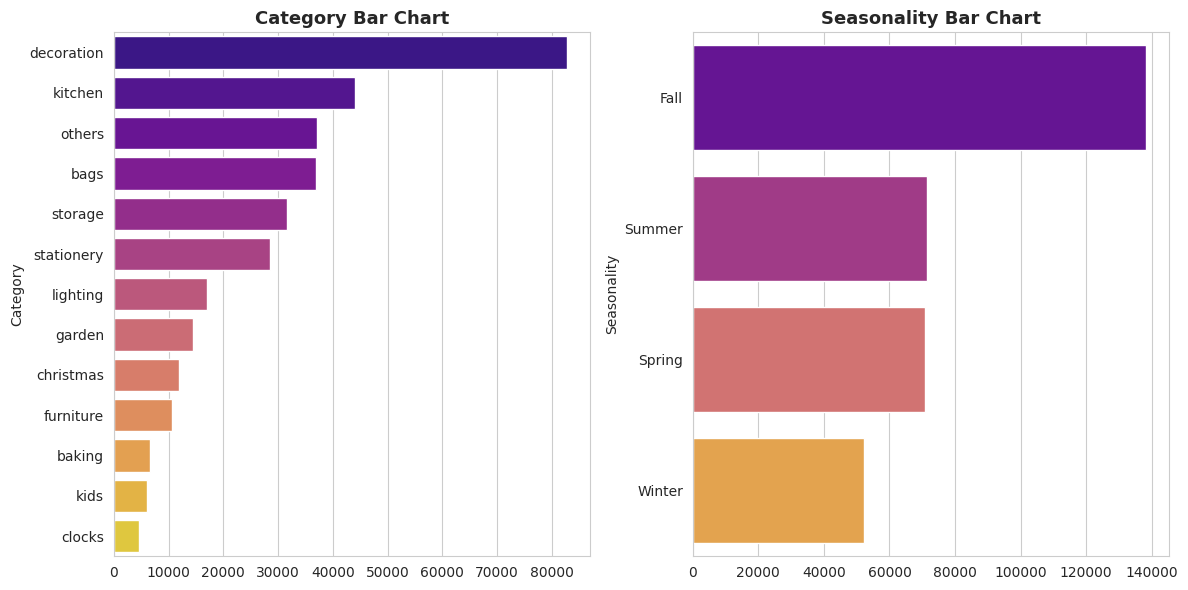

In [103]:
# Menampilkan Bar Chart persebaran Category dan Seasonality
new_features = {
    'Category': df['Category'].value_counts(),
    'Seasonality': df['Seasonality'].value_counts()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, (key, item) in enumerate(new_features.items()):
    sns.barplot(x=item.values, y=item.index, ax=axes[i], palette='plasma', hue=item.index, legend=False)
    axes[i].set_title(f'{key} Bar Chart', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

In [104]:
# Menghitung Monetary dengan kolom Sales
df['Sales'] = df['Quantity'] * df['UnitPrice']

df.sort_values(by='Sales', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995.0,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,stationery,Winter,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215.0,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,storage,Winter,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60.0,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,storage,Summer,38970.00
173382,551697,POST,POSTAGE,1.0,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,stationery,Spring,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412.0,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,kitchen,Fall,7144.72
...,...,...,...,...,...,...,...,...,...,...,...
173391,C551699,M,Manual,-1.0,2011-05-03 14:12:00,6930.00,16029.0,United Kingdom,others,Spring,-6930.00
173277,C551685,POST,POSTAGE,-1.0,2011-05-03 12:51:00,8142.75,16029.0,United Kingdom,stationery,Spring,-8142.75
222681,C556445,M,Manual,-1.0,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,others,Summer,-38970.00
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215.0,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,storage,Winter,-77183.60


In [105]:
# Menghapus transaksi custonmer yang diretur
retur = (df.loc[df['Sales'] <= 0, 'CustomerID'] + '_' + df.loc[df['Sales'] <= 0, 'StockCode']) # (Nanti hapus kalau udh paham) jadi ditandai dulu CustomerID sama StockCode yang retur

df = df[~(df['CustomerID'] + '_' + df['StockCode']).isin(retur)] # (Ini hapus juga) jadi (~) itu fungsinya membalikkan value, jadi yang dikeep itu yang SELAIN dalam df retur

df.sort_values(by='Sales', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412.0,2011-09-20 11:05:00,5.060,17450.0,United Kingdom,kitchen,Fall,7144.720
244419,558526,23173,REGENCY TEAPOT ROSES,540.0,2011-06-30 11:01:00,8.150,17949.0,United Kingdom,kitchen,Summer,4401.000
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880.0,2011-08-04 18:06:00,1.450,12931.0,United Kingdom,decoration,Summer,4176.000
533812,581115,22413,METAL SIGN TAKE IT OR LEAVE IT,1404.0,2011-12-07 12:20:00,2.750,15195.0,United Kingdom,decoration,Winter,3861.000
348323,567423,22722,SET OF 6 SPICE TINS PANTRY DESIGN,852.0,2011-09-20 11:05:00,4.250,17450.0,United Kingdom,kitchen,Fall,3621.000
...,...,...,...,...,...,...,...,...,...,...,...
500313,578757,16216,LETTER SHAPE PENCIL SHARPENER,1.0,2011-11-25 11:41:00,0.060,12748.0,United Kingdom,stationery,Fall,0.060
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2011-04-15 09:27:00,0.001,13952.0,United Kingdom,decoration,Spring,0.001
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2011-09-25 14:58:00,0.001,16198.0,United Kingdom,decoration,Fall,0.001
361741,568375,BANK CHARGES,Bank Charges,1.0,2011-09-26 17:01:00,0.001,13405.0,United Kingdom,others,Fall,0.001


## RFM

In [106]:
# Membuat kolom RFM
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

Recency = ('InvoiceDate', lambda x: (analysis_date - x.max()).days)
Frequency = ('InvoiceNo', 'nunique')
Monetary = ('Sales', 'sum')

In [107]:
# Membuat df RFM
df_rfm = df.groupby('CustomerID').agg(
    Recency=Recency,
    Frequency=Frequency,
    Monetary=Monetary
).reset_index()

df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12747.0,2,9,3489.74
1,12748.0,1,164,24890.80
2,12749.0,4,4,2916.51
3,12820.0,3,4,942.34
4,12821.0,214,1,92.72
...,...,...,...,...
3783,18280.0,278,1,180.60
3784,18281.0,181,1,80.82
3785,18282.0,8,2,164.13
3786,18283.0,4,16,2045.53


In [108]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3788 entries, 0 to 3787
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  3788 non-null   object 
 1   Recency     3788 non-null   int64  
 2   Frequency   3788 non-null   int64  
 3   Monetary    3788 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 118.5+ KB


In [109]:
df_rfm.describe(include='all')

,CustomerID,Recency,Frequency,Monetary
count,3788,3788.000000,3788.000000,3788.000000
unique,3788,NaN,NaN,NaN
top,18287.0,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,84.466737,3.956969,1531.199690
std,NaN,89.506352,6.321089,5771.277041
min,NaN,1.000000,1.000000,2.900000
25%,NaN,17.000000,1.000000,280.542500
50%,NaN,47.000000,2.000000,615.875000
75%,NaN,128.000000,4.000000,1465.527500


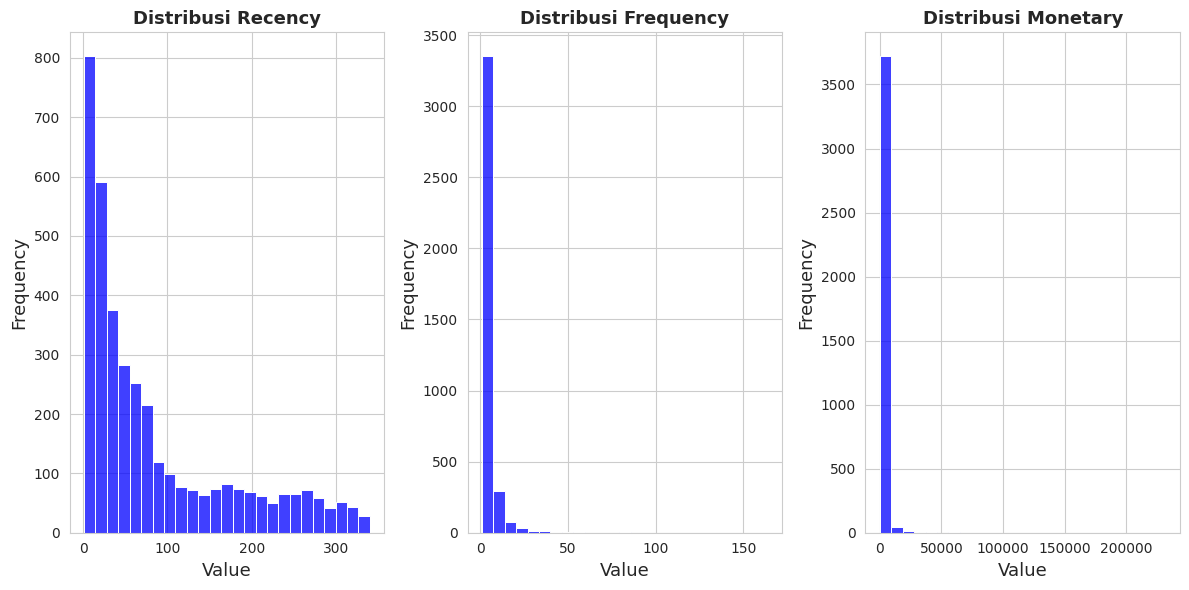

In [110]:
# Menampilkan Bar Chart kolom RFM
columns = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, column in enumerate(columns):
  sns.histplot(data=df_rfm[column], bins=25, color='blue', ax=axes[i])
  axes[i].set_title(f'Distribusi {column}', fontsize=13, weight='bold')
  axes[i].set_xlabel('Value', fontsize=13)
  axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

In [111]:
# Menerapkan Log Transformation
df_rfm_log = df_rfm.copy()
df_rfm_log[columns] = np.log1p(df_rfm_log[columns])

df_rfm_log.head()

,CustomerID,Recency,Frequency,Monetary
0,12747.0,1.098612,2.302585,8.157869
1,12748.0,0.693147,5.105945,10.122294
2,12749.0,1.609438,1.609438,7.978486
3,12820.0,1.386294,1.609438,6.849427
4,12821.0,5.370638,0.693147,4.540312


In [112]:
# Menerapkan Standarization
df_rfm_scaled = df_rfm_log.copy()

scaler = RobustScaler()
df_rfm_scaled[columns] = scaler.fit_transform(df_rfm_scaled[columns])

df_rfm_scaled.head()

,CustomerID,Recency,Frequency,Monetary
0,12747.0,-1.407805,1.313964,1.050191
1,12748.0,-1.613683,4.373430,2.240485
2,12749.0,-1.148429,0.557493,0.941498
3,12820.0,-1.261732,0.557493,0.257373
4,12821.0,0.761352,-0.442507,-1.141778


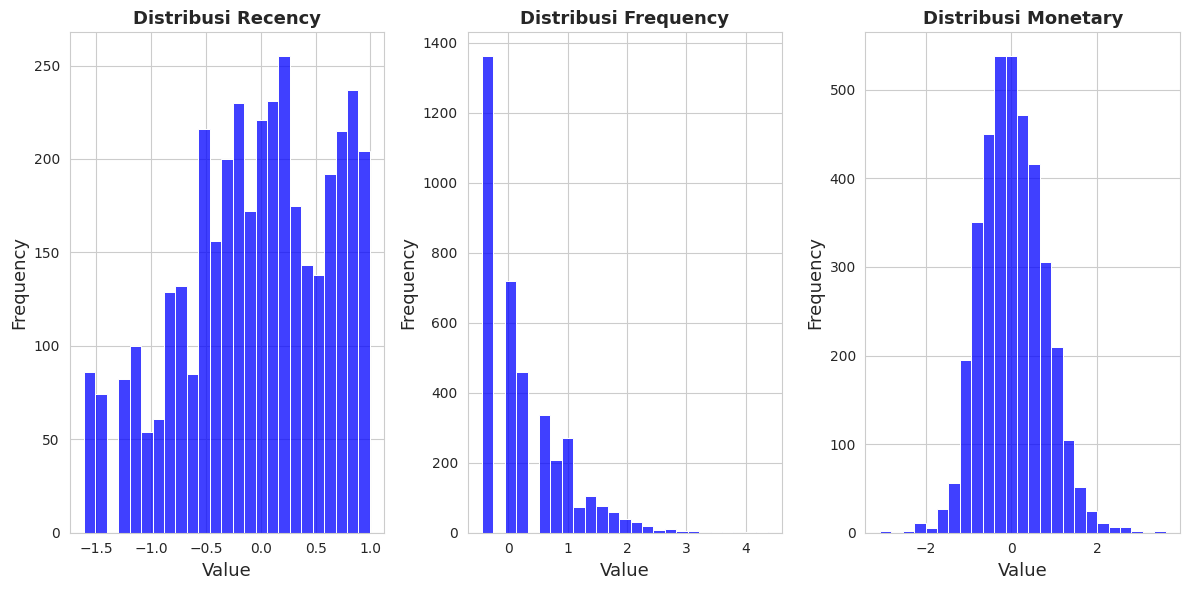

In [113]:
# Menampilkan Bar Chart kolom RFM setelah Log Transformation dan Standarization
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, column in enumerate(columns):
    sns.histplot(data=df_rfm_scaled[column], bins=25, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribusi {column}', fontsize=13, weight='bold')
    axes[i].set_xlabel('Value', fontsize=13)
    axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

In [114]:
# Melakukan Binning pada kolom Frequency
bin_columns = ['Recency', 'FrequencyBin', 'Monetary']
bins = [-np.inf, 0, 1, 2, np.inf]
bin_labels = ['Low', 'Medium', 'High', 'Very High']

df_rfm_binned = df_rfm_scaled.copy()
df_rfm_binned['FrequencyBin'] = pd.cut(df_rfm_binned['Frequency'], bins=bins, labels=bin_labels)

le = LabelEncoder()
df_rfm_binned['FrequencyBin'] = le.fit_transform(df_rfm_binned['FrequencyBin'])

df_rfm_binned.head()

,CustomerID,Recency,Frequency,Monetary,FrequencyBin
0,12747.0,-1.407805,1.313964,1.050191,0
1,12748.0,-1.613683,4.373430,2.240485,3
2,12749.0,-1.148429,0.557493,0.941498,2
3,12820.0,-1.261732,0.557493,0.257373,2
4,12821.0,0.761352,-0.442507,-1.141778,1


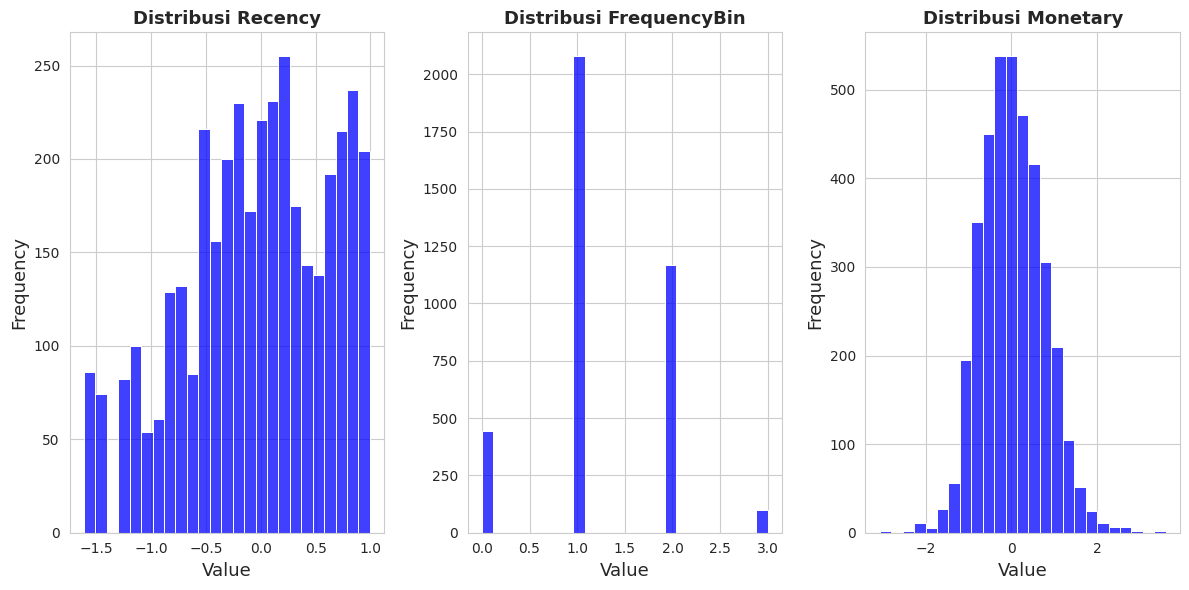

In [115]:
# Menampilkan Bar Chart kolom RFM setelah Binnning
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, column in enumerate(bin_columns):
    sns.histplot(data=df_rfm_binned[column], bins=25, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribusi {column}', fontsize=13, weight='bold')
    axes[i].set_xlabel('Value', fontsize=13)
    axes[i].set_ylabel('Frequency', fontsize=13)

fig.tight_layout()
plt.show()

# **Clustering**

## KMeans++

In [116]:
# Mencari best param model KMeans++
X_model = df_rfm_binned[bin_columns].values
kmeans = KMeans()

for n_clusters in range(3, 6):
    kmeans.set_params(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_model)
    labels = kmeans.labels_

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_clusters = 3, silhouette_score: 0.45616107971753855, calinski_score: 2640.302683282101, davies_score, 0.8393342698369363
n_clusters = 4, silhouette_score: 0.37335090766776957, calinski_score: 2502.925464062237, davies_score, 0.9686157842126104
n_clusters = 5, silhouette_score: 0.38502949175394946, calinski_score: 2541.786065151009, davies_score, 0.9885175142649633


In [117]:
# Membuat fungsi analisa cluster
def analyze_clusters(X, labels, n):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(n):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

In [118]:
# Menganalisa hasil clustering KMeans++
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_model)
labels = kmeans.labels_

df_kmeans = df_rfm.copy()
df_kmeans['Cluster'] = labels

analyze_clusters(X_model, labels, k)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.30109459903974367
Rata-rata (mean) Frequency: 1.037837837837838
Rata-rata (mean) Monetary: -0.46516164728063697

Cluster 2:
Rata-rata (mean) Recency: -0.6833051605355627
Rata-rata (mean) Frequency: 0.2275132275132275
Rata-rata (mean) Monetary: 0.7960242664158261

Cluster 3:
Rata-rata (mean) Recency: -0.35678781125081366
Rata-rata (mean) Frequency: 2.081787521079258
Rata-rata (mean) Monetary: 0.4985257035756549

Silhouette Score: 0.45616107971753855


In [119]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_kmeans['Recency'],
    y= df_kmeans['Frequency'],
    z= df_kmeans['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_kmeans['Cluster'],
        size= 12,
        line=dict(
            color= df_kmeans['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D KMeans++',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA KMeans++

In [120]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10, max_iter=300)
kmeans_pca.fit(df_PCA)

labels = kmeans_pca.predict(df_PCA)

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5791210223649272


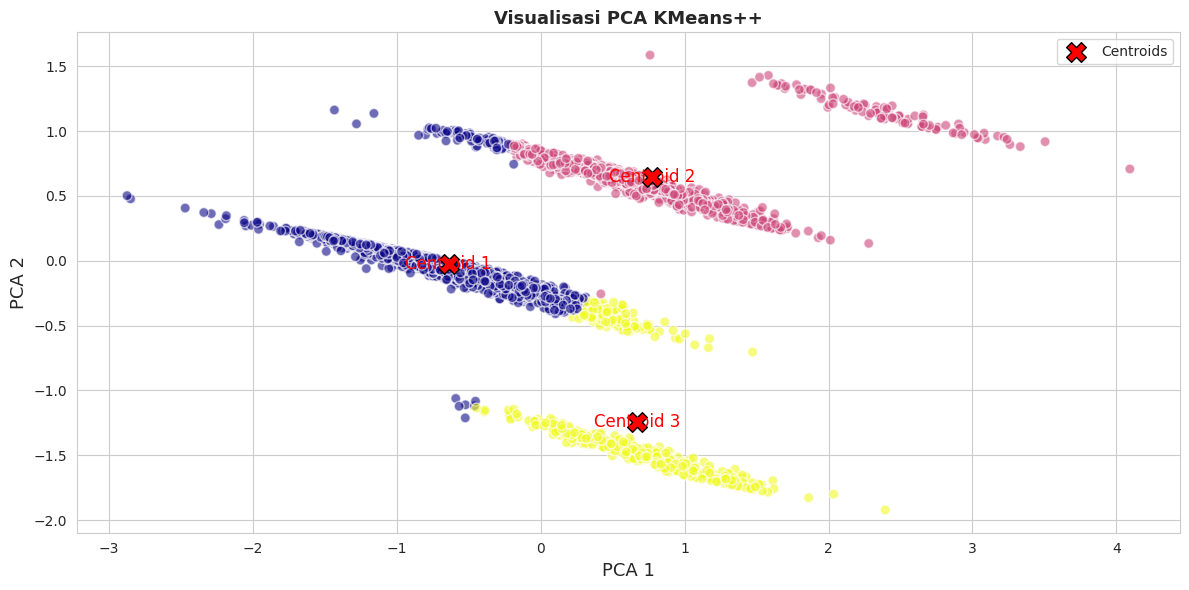


Nilai Centroids:
Centroid 1: PCA 1 = -0.64, PCA 2 = -0.03
Centroid 2: PCA 1 = 0.77, PCA 2 = 0.65
Centroid 3: PCA 1 = 0.67, PCA 2 = -1.24


In [121]:
# Menampilkan visualisasi 2D dari hasil Clustering
centroids = kmeans_pca.cluster_centers_

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA KMeans++', fontsize=13, weight='bold')
ax.legend()
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)

fig.tight_layout()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## Spectral Clustering

In [122]:
# Mencari best param model Spectral
X_model = df_rfm_binned[bin_columns].values
spectral = SpectralClustering()

for n_clusters in range(3, 6):
    spectral.set_params(n_clusters=n_clusters)
    spectral.fit(X_model)
    labels = spectral.labels_

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_clusters = 3, silhouette_score: 0.41529039830456493, calinski_score: 1104.3715650546621, davies_score, 0.6875672784634697
n_clusters = 4, silhouette_score: 0.39055636832149637, calinski_score: 722.1844027812127, davies_score, 0.8780346273964095
n_clusters = 5, silhouette_score: 0.42815878492411746, calinski_score: 1579.6717281933875, davies_score, 0.8918208527732379


In [123]:
# Menganalisa hasil clustering Spectral
s = 5
spectral = SpectralClustering(n_clusters=s)
spectral.fit(X_model)
labels = spectral.labels_

df_spectral = df_rfm.copy()
df_spectral['Cluster'] = labels

analyze_clusters(X_model, labels, s)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.23112719419814473
Rata-rata (mean) Frequency: 1.0098176718092566
Rata-rata (mean) Monetary: -0.42857964514708824

Cluster 2:
Rata-rata (mean) Recency: -1.21564542366354
Rata-rata (mean) Frequency: 3.0
Rata-rata (mean) Monetary: 1.6157526958836432

Cluster 3:
Rata-rata (mean) Recency: -0.701742969104373
Rata-rata (mean) Frequency: 0.0
Rata-rata (mean) Monetary: 0.9872498334321369

Cluster 4:
Rata-rata (mean) Recency: -1.3141175708017943
Rata-rata (mean) Frequency: 3.0
Rata-rata (mean) Monetary: 2.4709922055078275

Cluster 5:
Rata-rata (mean) Recency: -0.2642864659670776
Rata-rata (mean) Frequency: 2.0025906735751295
Rata-rata (mean) Monetary: 0.39864484794988986

Silhouette Score: 0.42815878492411746


In [124]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_spectral['Recency'],
    y= df_spectral['Frequency'],
    z= df_spectral['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_spectral['Cluster'],
        size= 12,
        line=dict(
            color= df_spectral['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D Spectral',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA Spectral

In [125]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

spectral_pca = SpectralClustering(n_clusters=s)
spectral_pca.fit(X_model)
labels = spectral_pca.labels_

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5562622062911365


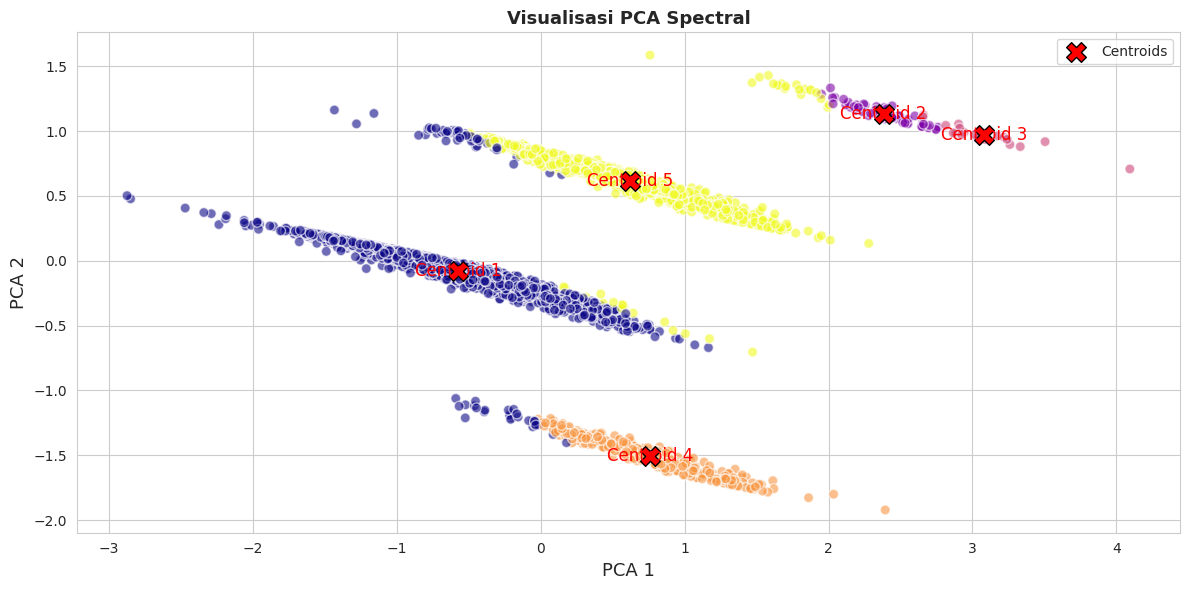


Nilai Centroids:
Centroid 1: PCA 1 = -0.58, PCA 2 = -0.08
Centroid 2: PCA 1 = 2.38, PCA 2 = 1.13
Centroid 3: PCA 1 = 3.08, PCA 2 = 0.97
Centroid 4: PCA 1 = 0.76, PCA 2 = -1.51
Centroid 5: PCA 1 = 0.62, PCA 2 = 0.61


In [126]:
# Menampilkan visualisasi 2D dari hasil Clustering
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

# (Delete this) jadi karena spectral gapunya cluster center maka harus dihitung manual meansnya
unique_labels = set(labels)
centroids_spectral = []

for i in unique_labels:
    sum_x = 0
    sum_y = 0
    count = 0

    for j in range(len(labels)):
        if labels[j] == i:
            sum_x += X_pca[j, 0]
            sum_y += X_pca[j, 1]
            count += 1

    centroid_x = sum_x / count
    centroid_y = sum_y / count

    centroids_spectral.append([centroid_x, centroid_y])

centroids_spectral = np.array(centroids_spectral)
ax.scatter(centroids_spectral[:, 0], centroids_spectral[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids_spectral):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA Spectral', fontsize=13, weight='bold')
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)
ax.legend()

fig.tight_layout()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids_spectral):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## GMM

In [127]:
# Mencari best param model Spectral
X_model = df_rfm_binned[bin_columns].values
gmm = GaussianMixture()

for n_components in range(3, 6):
    gmm.set_params(n_components=n_components)
    gmm.fit(X_model)
    labels = gmm.predict(X_model)

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_components = {n_components}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_components = 3, silhouette_score: 0.44780361880483655, calinski_score: 2459.0067333651373, davies_score, 0.8582237955132882
n_components = 4, silhouette_score: 0.33708919866279163, calinski_score: 2183.9460858202415, davies_score, 0.9650659144563433
n_components = 5, silhouette_score: 0.3651564179392685, calinski_score: 2203.3395510989294, davies_score, 0.8945522013071265


In [128]:
# Menganalisa hasil clustering Spectral
g = 3
gmm = GaussianMixture(n_components=g, random_state=42)
labels = gmm.fit_predict(X_model)

df_gmm = df_rfm.copy()
df_gmm['Cluster'] = labels

analyze_clusters(X_model, labels, g)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -0.6496665576224041
Rata-rata (mean) Frequency: 0.0
Rata-rata (mean) Monetary: 0.9466563681187476

Cluster 2:
Rata-rata (mean) Recency: -0.3001834990260918
Rata-rata (mean) Frequency: 2.0765588003157065
Rata-rata (mean) Monetary: 0.43888280128752655

Cluster 3:
Rata-rata (mean) Recency: 0.22589141443670527
Rata-rata (mean) Frequency: 1.0
Rata-rata (mean) Monetary: -0.4225557155639147

Silhouette Score: 0.44780361880483655


In [129]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_gmm['Recency'],
    y= df_gmm['Frequency'],
    z= df_gmm['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_gmm['Cluster'],
        size= 12,
        line=dict(
            color= df_gmm['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D GMM',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA GMM

In [130]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

gmm_pca = GaussianMixture(n_components=g, random_state=42)
gmm_pca.fit(df_PCA)

labels = gmm_pca.predict(df_PCA)

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5674848590246054


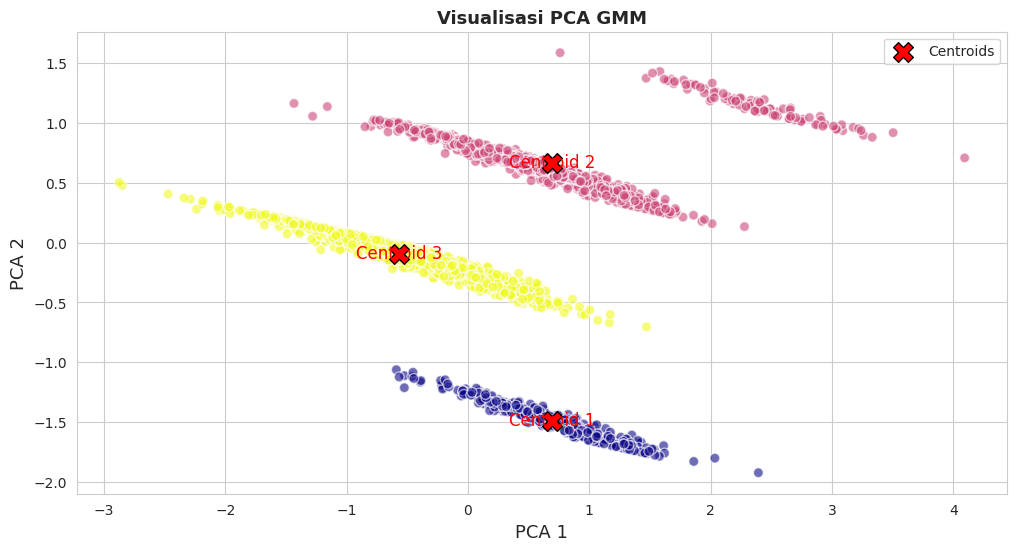


Nilai Centroids:
Centroid 1: PCA 1 = 0.70, PCA 2 = -1.49
Centroid 2: PCA 1 = 0.69, PCA 2 = 0.67
Centroid 3: PCA 1 = -0.57, PCA 2 = -0.09


In [131]:
# Menampilkan visualisasi 2D dari hasil Clustering
centroids = gmm_pca.means_ # (Delete this) kalau GMM pakainya means

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA GMM', fontsize=13, weight='bold')
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)
ax.legend()

plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## HDBSCAN

In [132]:
# Mencari best param model HDBSCAN
X_model = df_rfm_binned[bin_columns].values
hdb = HDBSCAN()

for n_params in range(3, 6):
    hdb.set_params(min_cluster_size=n_params, min_samples=n_params)
    labels = hdb.fit_predict(X_model)

    silhouette_avg = silhouette_score(X_model, labels)
    calinski_avg = calinski_harabasz_score(X_model, labels)
    davies_avg = davies_bouldin_score(X_model, labels)

    print(f'n_params = {n_params}, silhouette_score: {silhouette_avg}, calinski_score: {calinski_avg}, davies_score, {davies_avg}')

n_params = 3, silhouette_score: 0.08345668949273145, calinski_score: 15.232611194572755, davies_score, 1.3725970440508999
n_params = 4, silhouette_score: -0.0537359389690494, calinski_score: 23.40831753224457, davies_score, 1.3623522091952982
n_params = 5, silhouette_score: 0.4305117983560978, calinski_score: 1582.401428813947, davies_score, 0.7090123933265916


In [133]:
# Menganalisa hasil clustering HDBSCAN
h = 5
hdb = HDBSCAN(min_cluster_size=h, min_samples=h)

hdb.fit(X_model)
labels = hdb.labels_

df_hdb = df_rfm.copy()
df_hdb['Cluster'] = labels

analyze_clusters(X_model, labels, labels.max() + 1)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -1.135239817859194
Rata-rata (mean) Frequency: 3.0
Rata-rata (mean) Monetary: 1.6964368524038247

Cluster 2:
Rata-rata (mean) Recency: -0.6485355766287277
Rata-rata (mean) Frequency: 0.0
Rata-rata (mean) Monetary: 0.9424002026074376

Cluster 3:
Rata-rata (mean) Recency: 0.22589141443670527
Rata-rata (mean) Frequency: 1.0
Rata-rata (mean) Monetary: -0.4225557155639147

Cluster 4:
Rata-rata (mean) Recency: -0.23095233413138164
Rata-rata (mean) Frequency: 2.0
Rata-rata (mean) Monetary: 0.33462404662232914

Silhouette Score: 0.4305117983560978


In [134]:
# Menampilkan visualisasi 3D dari hasil Clustering
visual_3d = go.Scatter3d(
    x= df_hdb['Recency'],
    y= df_hdb['Frequency'],
    z= df_hdb['Monetary'],
    hovertemplate=(
        "Recency: %{x}<br>"
        "Frequency: %{y}<br>"
        "Monetary: %{z:.2f}"),
    mode='markers',
    marker=dict(
        color = df_hdb['Cluster'],
        size= 12,
        line=dict(
            color= df_hdb['Cluster'],
            width= 6
        ),
        opacity=0.8
    )
)

data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D HDBSCAN',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)

fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA HDBCSAN

In [135]:
# Melakukan reduksi dimensi data dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

hdb_pca = HDBSCAN(min_cluster_size=h, min_samples=h)
hdb_pca.fit(X_model)
labels = hdb_pca.labels_

score = silhouette_score(df_PCA, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5589132176127274


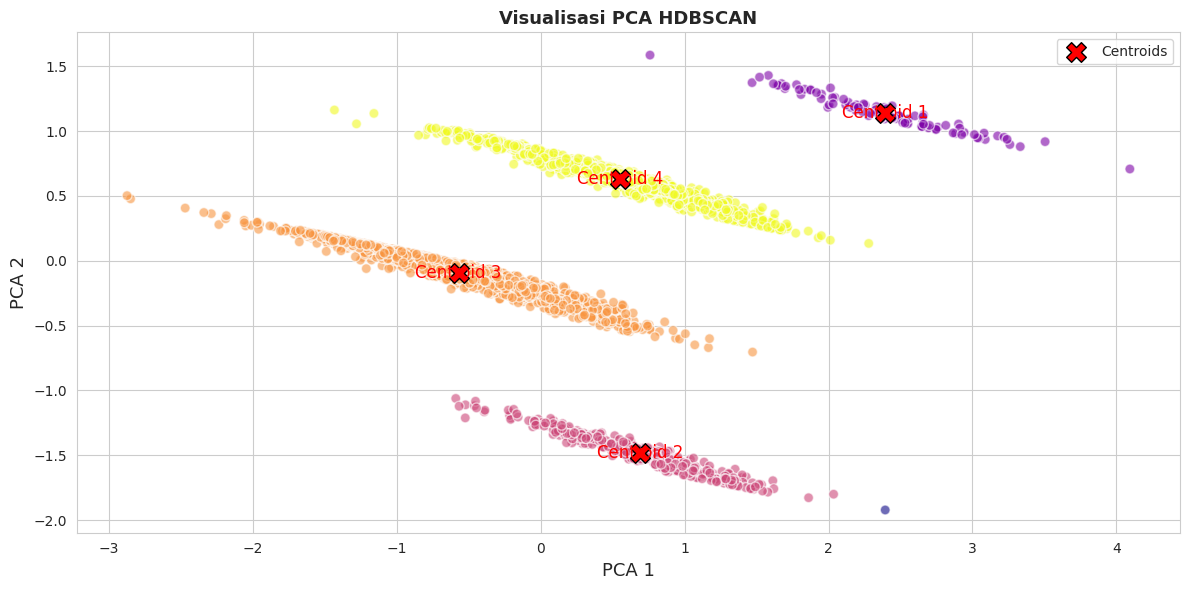


Nilai Centroids:
Centroid 1: PCA 1 = 2.39, PCA 2 = 1.14
Centroid 2: PCA 1 = 0.69, PCA 2 = -1.49
Centroid 3: PCA 1 = -0.57, PCA 2 = -0.09
Centroid 4: PCA 1 = 0.55, PCA 2 = 0.63


In [136]:
# Menampilkan visualisasi 2D dari hasil Clustering
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma', s=50, alpha=0.6, edgecolors='w', marker='o')

# (Delete this) caranya sama kyk spectral
unique_labels = set(labels)
unique_labels.discard(-1)
centroids_spectral = []

for i in unique_labels:
    sum_x = 0
    sum_y = 0
    count = 0

    for j in range(len(labels)):
        if labels[j] == i:
            sum_x += X_pca[j, 0]
            sum_y += X_pca[j, 1]
            count += 1

    centroid_x = sum_x / count
    centroid_y = sum_y / count

    centroids_spectral.append([centroid_x, centroid_y])

centroids_spectral = np.array(centroids_spectral)
ax.scatter(centroids_spectral[:, 0], centroids_spectral[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids_spectral):
    ax.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

ax.set_title('Visualisasi PCA HDBSCAN', fontsize=13, weight='bold')
ax.set_xlabel('PCA 1', fontsize=13)
ax.set_ylabel('PCA 2', fontsize=13)
ax.legend()

fig.tight_layout()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids_spectral):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

### Cluster Labeling

In [137]:
# Menghapus Cluster Outlier (-1)
df_hdb = df_hdb[df_hdb['Cluster'] != -1]
df_hdb.describe(include='all')

,CustomerID,Recency,Frequency,Monetary,Cluster
count,3787,3787.000000,3787.000000,3787.000000,3787.000000
unique,3787,NaN,NaN,NaN,NaN
top,18287.0,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,84.487985,3.953525,1514.396523,2.141273
std,NaN,89.508617,6.318368,5678.611241,0.712765
min,NaN,1.000000,1.000000,2.900000,0.000000
25%,NaN,17.000000,1.000000,280.535000,2.000000
50%,NaN,47.000000,2.000000,615.490000,2.000000
75%,NaN,128.000000,4.000000,1463.985000,3.000000


In [138]:
# Melakukan analisa cluster
cluster_analysis = df_hdb.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_scaled)) * 100)
).reset_index().sort_values(by='Cluster')

cluster_analysis

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
0,0,6.164948,31.144330,17212.509175,97,2.560718
1,1,21.943311,9.959184,3597.595737,441,11.642027
2,2,119.924964,1.345358,430.092767,2079,54.883844
3,3,51.587179,4.070085,1354.447574,1170,30.887012


In [139]:
# Memberikan label pada cluster
cluster_label = {
    0: 'Loyal Customer',
    1: 'Regular Customer',
    2: 'Churn/One Time Spender',
    3: 'High Risk Churn'
}

cluster_analysis['Label'] = cluster_analysis['Cluster'].map(cluster_label)

cluster_analysis

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage,Label
0,0,6.164948,31.144330,17212.509175,97,2.560718,Loyal Customer
1,1,21.943311,9.959184,3597.595737,441,11.642027,Regular Customer
2,2,119.924964,1.345358,430.092767,2079,54.883844,Churn/One Time Spender
3,3,51.587179,4.070085,1354.447574,1170,30.887012,High Risk Churn


# **Post-processing**

In [140]:
# Menyatukan label ke dalam df RFM
cluster_to_label = cluster_analysis['Label'].to_dict()

df_hdb['Label'] = df_hdb['Cluster'].map(cluster_to_label)

df_hdb.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Label
0,12747.0,2,9,3489.74,1,Regular Customer
1,12748.0,1,164,24890.80,0,Loyal Customer
2,12749.0,4,4,2916.51,3,High Risk Churn
3,12820.0,3,4,942.34,3,High Risk Churn
4,12821.0,214,1,92.72,2,Churn/One Time Spender


In [141]:
# Menyatukan df RFM kembali ke df Raw Data
df_final = df.copy()
df_final = df_final.merge(
    df_hdb[['CustomerID', 'Cluster', 'Label']],
    on='CustomerID',
    how='inner'
)

df_final

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales,Cluster,Label
0,539993,22386,JUMBO BAG PINK POLKADOT,10.0,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,bags,Winter,19.5,3,High Risk Churn
1,539993,21499,BLUE POLKADOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery,Winter,10.5,3,High Risk Churn
2,539993,21498,RED RETROSPOT WRAP,25.0,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery,Winter,10.5,3,High Risk Churn
3,539993,22379,RECYCLING BAG RETROSPOT,5.0,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,bags,Winter,10.5,3,High Risk Churn
4,539993,20718,RED RETROSPOT SHOPPER BAG,10.0,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,bags,Winter,12.5,3,High Risk Churn
...,...,...,...,...,...,...,...,...,...,...,...,...,...
307444,581585,23145,ZINC T-LIGHT HOLDER STAR LARGE,12.0,2011-12-09 12:31:00,0.95,15804.0,United Kingdom,lighting,Winter,11.4,1,Regular Customer
307445,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12.0,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,lighting,Winter,23.4,1,Regular Customer
307446,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24.0,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,decoration,Winter,30.0,0,Loyal Customer
307447,581586,21217,RED RETROSPOT ROUND CAKE TINS,24.0,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,storage,Winter,214.8,0,Loyal Customer


In [142]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307449 entries, 0 to 307448
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    307449 non-null  object        
 1   StockCode    307449 non-null  object        
 2   Description  307449 non-null  object        
 3   Quantity     307449 non-null  float64       
 4   InvoiceDate  307449 non-null  datetime64[ns]
 5   UnitPrice    307449 non-null  float64       
 6   CustomerID   307449 non-null  object        
 7   Country      307449 non-null  object        
 8   Category     307449 non-null  object        
 9   Seasonality  307449 non-null  object        
 10  Sales        307449 non-null  float64       
 11  Cluster      307449 non-null  int64         
 12  Label        307449 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 30.5+ MB


In [143]:
df_final.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Category,Seasonality,Sales,Cluster,Label
count,307449,307449,307449,307449.000000,307449,307449.000000,307449,307449,307449,307449,307449.000000,307449.000000,307449
unique,14972,3564,3737,NaN,NaN,NaN,3787,1,13,4,NaN,NaN,4
top,567183,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841.0,United Kingdom,decoration,Fall,NaN,NaN,High Risk Churn
freq,390,1596,1590,NaN,NaN,NaN,6087,307449,77212,126942,NaN,NaN,103929
mean,NaN,NaN,NaN,11.247374,2011-07-25 20:58:23.847857408,2.795372,NaN,NaN,NaN,NaN,18.653564,1.706634,NaN
min,NaN,NaN,NaN,1.000000,2011-01-04 10:00:00,0.001000,NaN,NaN,NaN,NaN,0.001000,0.000000,NaN
25%,NaN,NaN,NaN,2.000000,2011-05-03 15:12:00,1.250000,NaN,NaN,NaN,NaN,4.200000,1.000000,NaN
50%,NaN,NaN,NaN,4.000000,2011-08-15 11:30:00,1.690000,NaN,NaN,NaN,NaN,10.200000,2.000000,NaN
75%,NaN,NaN,NaN,12.000000,2011-10-26 10:43:00,3.750000,NaN,NaN,NaN,NaN,17.700000,3.000000,NaN
max,NaN,NaN,NaN,4300.000000,2011-12-09 12:49:00,2033.100000,NaN,NaN,NaN,NaN,7144.720000,3.000000,NaN


In [144]:
# Menyimpan hasil Clustering
df_final.to_csv('online_retail_uci_clustering.csv', index=False)

# **Intepretasi Hasil Clustering**

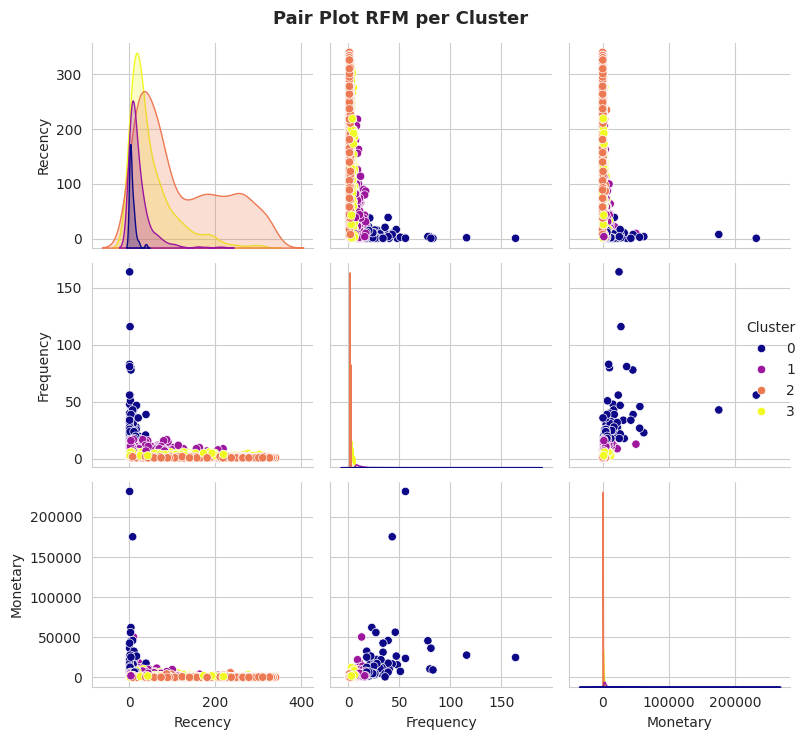

In [145]:
# Menampilkan Pair Plot masing-masing variabel pada RFM per Cluster
pairplot = sns.pairplot(data=df_hdb, vars=columns, hue='Cluster', palette='plasma')
fig = pairplot.fig
fig.suptitle('Pair Plot RFM per Cluster', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

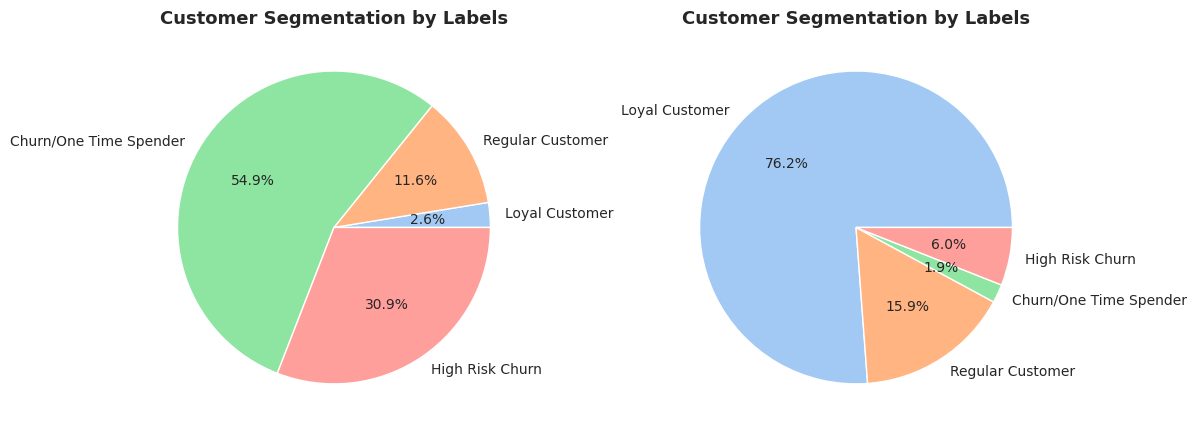

In [146]:
# Menampikan Pie Chart segmentasi Customer per Cluster
values = []
labels = []

values.append(cluster_analysis['Percentage'])
labels.append(cluster_analysis['Label'])

values.append(cluster_analysis['Avg_Monetary'])
labels.append(cluster_analysis['Label'])

fig, axes = plt.subplots(1, 2, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.pie(x=values[i], labels=labels[i], autopct='%1.1f%%', colors=sns.color_palette('pastel', len(labels[i])))
    ax.set_title('Customer Segmentation by Labels', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

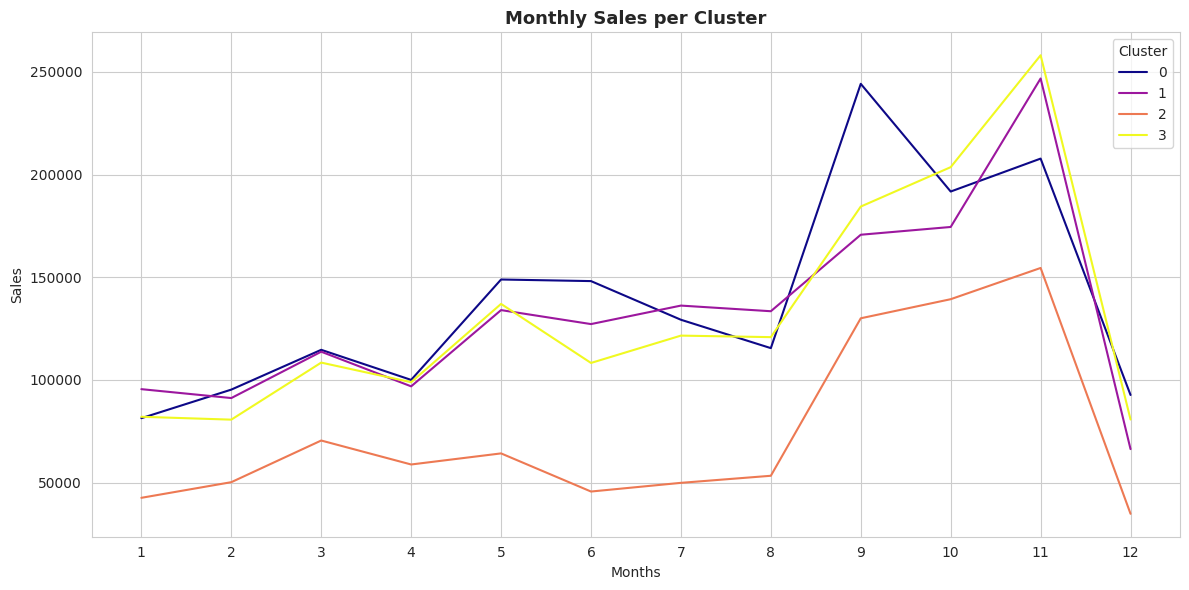

In [147]:
# Menampikan Line Chart total Sales masing-masing Cluster per Months
df_months = df_final.copy()
df_months['Months'] = df_months['InvoiceDate'].dt.month
monthly_sales_cluster = df_months.groupby(['Cluster', 'Months'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.lineplot(x='Months', y='Sales', data=monthly_sales_cluster, palette='plasma', hue='Cluster', ax=ax)
ax.set_title('Monthly Sales per Cluster', fontsize=13, weight='bold')
ax.set_xticks(range(1, 13))

fig.tight_layout()
plt.show()

Melakukan Analisa Category per Cluster

In [148]:
# Menampilkan rasio transaksi Customer per Category
sales_by_category = df_final.groupby(['CustomerID', 'Cluster', 'Category'])['Sales'].sum().unstack()

sales_by_category.head()

,Category,bags,baking,christmas,clocks,decoration,furniture,garden,kids,kitchen,lighting,others,stationery,storage
CustomerID,Cluster,,,,,,,,,,,,,
12747.0,1,384.80,NaN,NaN,NaN,888.04,205.50,130.60,NaN,60.35,188.40,1632.05,NaN,NaN
12748.0,0,1967.26,439.12,1103.90,183.1,5301.11,376.56,954.25,265.63,3354.11,2491.59,3878.04,2095.02,2481.11
12749.0,3,63.30,104.40,15.30,111.0,780.42,237.70,59.40,NaN,724.60,147.44,198.71,119.85,354.39
12820.0,3,118.80,NaN,165.72,NaN,258.52,NaN,NaN,9.36,32.00,84.60,37.80,114.60,120.94
12821.0,2,NaN,NaN,NaN,NaN,75.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.00


In [149]:
# Mengambil Category dengan transaksi tertinggi sebagai representasi Customer
most_spend_category = sales_by_category.idxmax(axis=1).reset_index() # (Delete this) idxmax buat ambil max salesnya
most_spend_category.columns = ['CustomerID', 'Cluster', 'Category']

most_spend_category.sample(10)

,CustomerID,Cluster,Category
1067,14381.0,2,decoration
26,12845.0,3,storage
298,13246.0,3,decoration
1318,14730.0,1,decoration
507,13551.0,2,others
1256,14643.0,2,kitchen
76,12928.0,3,bags
2514,16433.0,2,storage
3422,17742.0,2,decoration
2389,16255.0,1,decoration


In [150]:
clusters = 4
cluster_category = []
cluster_category_analysis = []

for i in range(clusters):
    cluster_category.append(most_spend_category[most_spend_category['Cluster'] == i])
    cluster_category_analysis.append(cluster_category[i].groupby('Category').agg(
        Count = ('CustomerID', 'count'),
        Percentage = ('CustomerID', lambda x: (x.count() / len(cluster_category[i])) * 100)
        ).reset_index())

In [151]:
cluster_category_analysis

[     Category  Count  Percentage
 0        bags     20   20.618557
 1      baking      1    1.030928
 2   christmas      1    1.030928
 3      clocks      3    3.092784
 4  decoration     57   58.762887
 5     kitchen      7    7.216495
 6    lighting      2    2.061856
 7      others      3    3.092784
 8     storage      3    3.092784,
       Category  Count  Percentage
 0         bags     73   16.553288
 1       baking      2    0.453515
 2    christmas      1    0.226757
 3       clocks      3    0.680272
 4   decoration    249   56.462585
 5    furniture     10    2.267574
 6       garden      2    0.453515
 7         kids      2    0.453515
 8      kitchen     46   10.430839
 9     lighting      7    1.587302
 10      others     23    5.215420
 11  stationery      7    1.587302
 12     storage     16    3.628118,
       Category  Count  Percentage
 0         bags    142    6.830207
 1       baking     36    1.731602
 2    christmas     68    3.270803
 3       clocks      9    0.

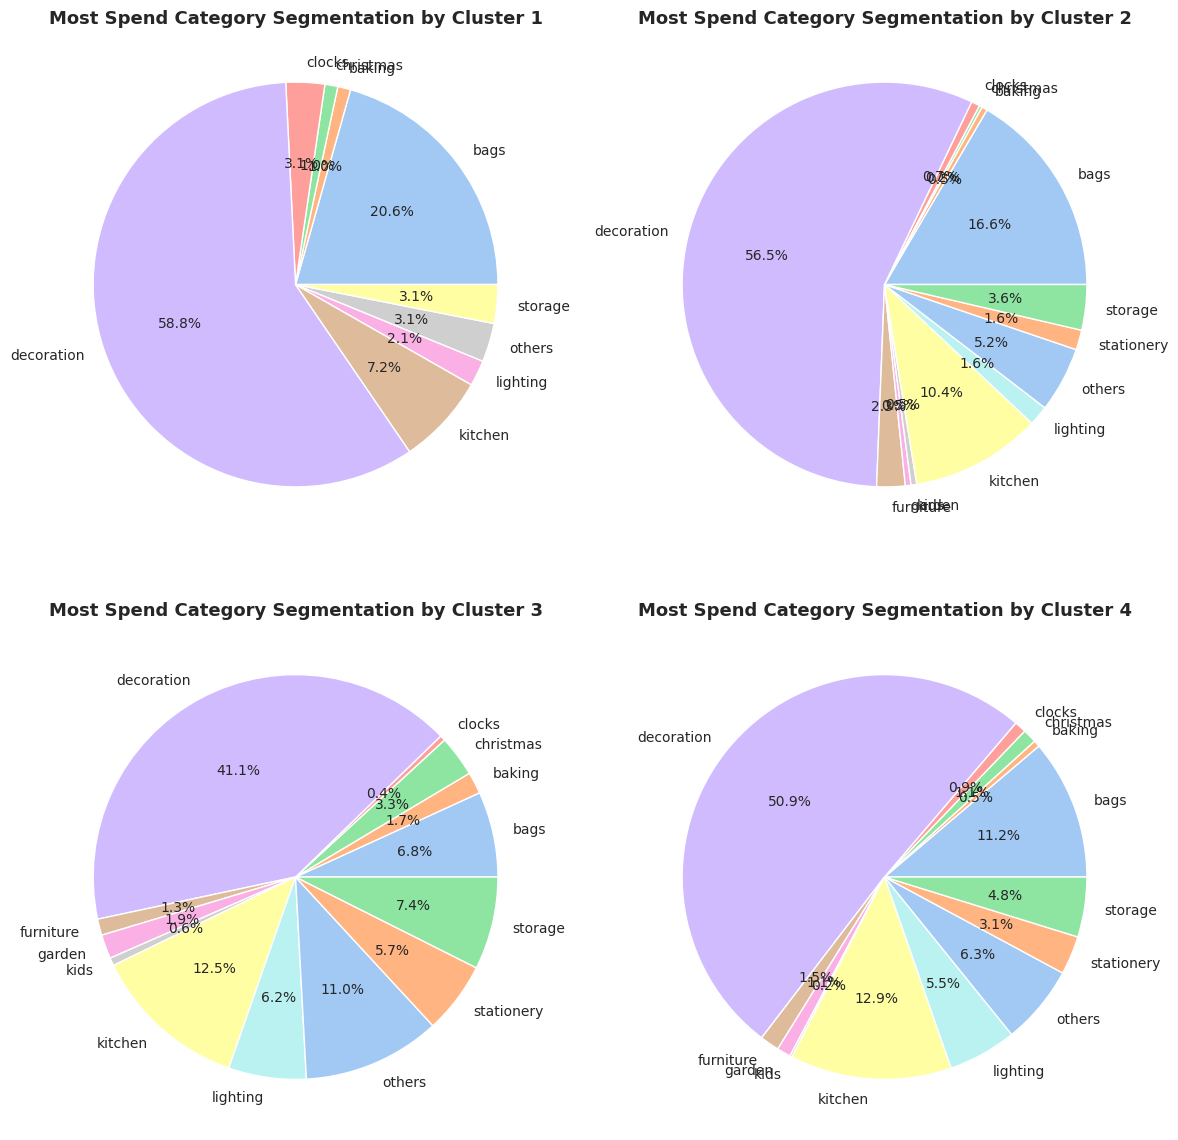

In [152]:
# Menampilkan Pie Chart rasio Category tertinggi per Cluster
values = []
labels = []

for i in range(clusters):
    values.append(cluster_category_analysis[i]['Percentage'])
    labels.append(cluster_category_analysis[i]['Category'])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.pie(x=values[i], labels=labels[i], autopct='%1.1f%%', colors = sns.color_palette('pastel', len(labels[i])))
    ax.set_title(f'Most Spend Category Segmentation by Cluster {i+1}', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

Melakukan Analisa Seasonality per Cluster

In [153]:
# Menampilkan rasio transaksi Customer per Seasonality
sales_by_seasonality = df_final.groupby(['CustomerID', 'Cluster', 'Seasonality'])['Sales'].sum().unstack()

sales_by_seasonality.head()

,Seasonality,Fall,Spring,Summer,Winter
CustomerID,Cluster,,,,
12747.0,1,988.11,1082.09,678.00,741.54
12748.0,0,15821.79,3684.28,3627.06,1757.67
12749.0,3,554.69,592.60,1153.46,615.76
12820.0,3,561.53,NaN,NaN,380.81
12821.0,2,NaN,92.72,NaN,NaN


In [154]:
# Mengambil Seasonality dengan transaksi tertinggi sebagai representasi Customer
most_spend_seasonality = sales_by_seasonality.idxmax(axis=1).reset_index() # (Delete this) idxmax buat ambil max salesnya
most_spend_seasonality.columns = ['CustomerID', 'Cluster', 'Seasonality']

most_spend_seasonality.sample(10)

,CustomerID,Cluster,Seasonality
2692,16698.0,2,Spring
183,13085.0,2,Summer
2898,16987.0,1,Fall
843,14049.0,3,Fall
459,13483.0,2,Fall
2714,16729.0,0,Spring
3006,17147.0,3,Fall
1528,15048.0,3,Spring
1893,15555.0,1,Fall
957,14215.0,3,Winter


In [155]:
clusters = 4
cluster_seasonality = []
cluster_seasonality_analysis = []

for i in range(clusters):
    cluster_seasonality.append(most_spend_seasonality[most_spend_seasonality['Cluster'] == i])
    cluster_seasonality_analysis.append(cluster_seasonality[i].groupby('Seasonality').agg(
        Count = ('CustomerID', 'count'),
        Percentage = ('CustomerID', lambda x: (x.count() / len(cluster_seasonality[i])) * 100)
        ).reset_index())

In [156]:
cluster_seasonality_analysis

[  Seasonality  Count  Percentage
 0        Fall     54   55.670103
 1      Spring     24   24.742268
 2      Summer     13   13.402062
 3      Winter      6    6.185567,
   Seasonality  Count  Percentage
 0        Fall    243   55.102041
 1      Spring     72   16.326531
 2      Summer     87   19.727891
 3      Winter     39    8.843537,
   Seasonality  Count  Percentage
 0        Fall    952   45.791246
 1      Spring    463   22.270322
 2      Summer    374   17.989418
 3      Winter    290   13.949014,
   Seasonality  Count  Percentage
 0        Fall    565   48.290598
 1      Spring    234   20.000000
 2      Summer    234   20.000000
 3      Winter    137   11.709402]

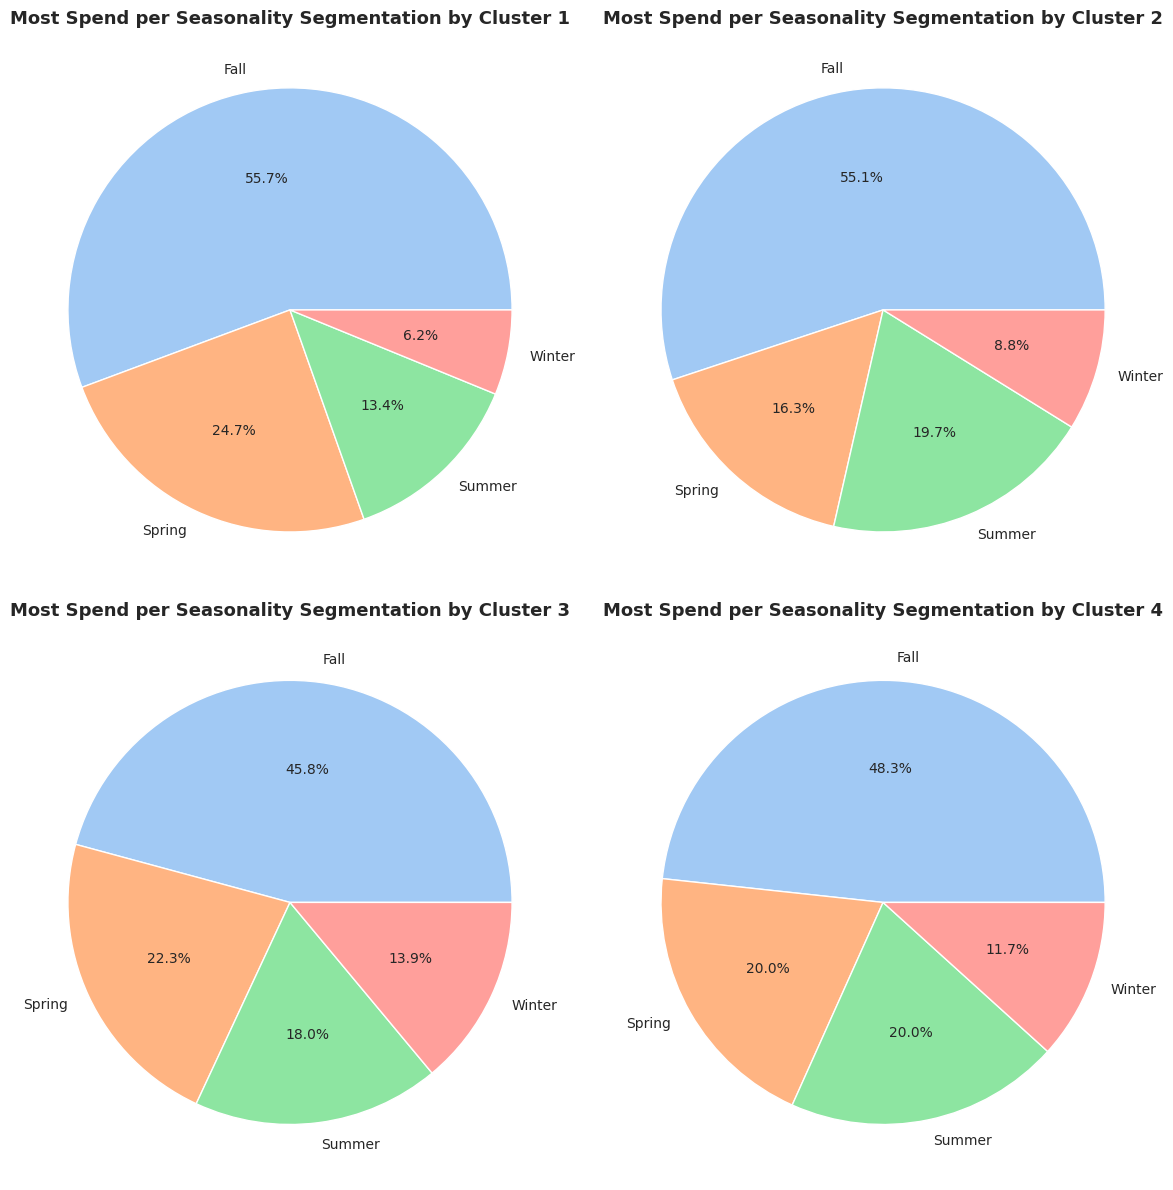

In [157]:
# Menampilkan Pie Chart rasio Seasonality tertinggi per Cluster
values = []
labels = []

for i in range(clusters):
    values.append(cluster_seasonality_analysis[i]['Percentage'])
    labels.append(cluster_seasonality_analysis[i]['Seasonality'])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.pie(x=values[i], labels=labels[i], autopct='%1.1f%%', colors=sns.color_palette('pastel', len(labels[i])))
    ax.set_title(f'Most Spend per Seasonality Segmentation by Cluster {i+1}', fontsize=13, weight='bold')

fig.tight_layout()
plt.show()

In [158]:
df_hdb.groupby('Cluster')[columns].agg(['mean', 'min', 'max'])

Recency           Frequency               Monetary          \
               mean min  max       mean min  max          mean     min   
Cluster                                                                  
0          6.164948   1   39  31.144330  18  164  17212.509175  726.69   
1         21.943311   1  218   9.959184   7   17   3597.595737  191.17   
2        119.924964   1  340   1.345358   1    2    430.092767    2.90   
3         51.587179   1  311   4.070085   3    6   1354.447574   20.35   

                    
               max  
Cluster             
0        231822.69  
1         50415.49  
2          6045.00  
3         12393.70

## Karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: Loyal Customer**
- **Rata-rata (mean) Recency:** 6.164948
- **Rata-rata (mean) Frequency:** 31.144330
- **Rata-rata (mean) Monetary:** 17212.509175
- **Kategori (Category):** Decoration, Bags
- **Musim (Seasonality):** Fall, Spring

- **Analisis:** Customer yang termasuk di cluster ini cenderung memiliki loyalitas tinggi dengan monetary yang tinggi. Pelanggan dalam cluster ini sering berbelanja.
- **Strategi marketing yang disarankan:** Prioritas VIP karena berdampak besar terhadap penjualan.
Contoh program yang dapat diterapkan adalah membership karena pelanggan akan datang untuk mendapatkan benefit dari membership.

2. **Cluster 2: Regular Customer**
- **Rata-rata (mean) Recency:** 21.943311
- **Rata-rata (mean) Frequency:** 9.959184
- **Rata-rata (mean) Monetary:** 3597.595737
- **Kategori (Category):** Decoration, Bags, Kitchen
- **Musim (Seasonality):** Fall, Summer

- **Analisis:** Customer pada cluster ini memiliki nilai RFM yang berada di tengah, mereka masih bertransaksi tetapi tidak berdampak besar terhadap penjualan.
- **Strategi marketing yang disarankan:** Berikan rekomendasi produk berkaitan dengan produk yang pernah dibeli customer.

3. **Cluster 3: Churn/One Time Spender**
- **Rata-rata (mean) Recency:** 119.924964
- **Rata-rata (mean) Frequency:** 1.345358
- **Rata-rata (mean) Monetary:** 430.092767
- **Kategori (Category):** Decoration, Kitchen, Others
- **Musim (Seasonality):** Fall, Spring

- **Analisis:** Customer dalam cluster ini pernah bertransaksi tetapi sekarang sudah tidak lagi.
- **Strategi marketing yang dapat digunakan:** Berikan promosi yang menarik agar mereka bertransaksi kembali contohnya dengan memberikan diskon yang besar bagi pelanggan yang dirasa memiliki nilai monetary bagus.
Jika dirasa tidak efisien, sebaiknya dianggap Churn karena tidak berdampak besar terhadap penjualan.

4. **Cluster 4: High Risk Churn**
- **Rata-rata (mean) Recency:** 51.587179
- **Rata-rata (mean) Frequency:** 4.070085
- **Rata-rata (mean) Monetary:** 1354.447574
- **Kategori (Category):** Decoration, Kitchen, Bags
- **Musim (Seasonality):** Fall, Spring, Summer

- **Analisis:** Customer dalam cluster ini masuk ke dalam kategori customer yang memiliki resiko untuk tidak lagi bertransaksi pada retail tersebut. customer pada cluster ini tergolong sudah lama tidak bertransaksi dengan frekuensi transaksi yang dibawah rata-rata. Dampak monetary yang diberikan juga tidak besar.
- **Strategi marketing yang disarankan:** Berikan quesioner alasan mereka sudah jarang bertransaksi (opsional) bisa juga digunakan untuk menarik kembali dengan cara memberikan pengalaman yang lebih baik setelah memperbaiki poin-poin customer.
Memberikan diskon agar customer lebih tertarik untuk bertransaksi.


End of Code.